# KKBOX Churn Prediction — Advanced Model Training

**Improvements over lite version:**
- ✅ LightGBM model added
- ✅ Ensemble (XGBoost + LightGBM)
- ✅ StratifiedKFold 5-fold cross-validation
- ✅ Advanced transaction features
- ✅ Better hyperparameters

**Memory optimized:** Still skips user_logs to avoid kernel crashes

## Step 0 — Configuration & Imports

In [1]:
# pandas: Main library for data manipulation and analysis (DataFrames)
import pandas as pd

# numpy: Numerical computing library for array operations and math functions
import numpy as np

# matplotlib.pyplot: Low-level plotting library for creating visualizations
import matplotlib.pyplot as plt

# seaborn: High-level statistical visualization library built on matplotlib
import seaborn as sns

# train_test_split: Split data into training and validation sets
# StratifiedKFold: K-fold cross-validation that preserves class distribution
from sklearn.model_selection import train_test_split, StratifiedKFold

# log_loss: Logarithmic loss metric (lower is better)
# roc_auc_score: Area under ROC curve metric (higher is better)
# confusion_matrix: Matrix showing true/false positives/negatives
# roc_curve: Compute ROC curve for visualization
from sklearn.metrics import log_loss, roc_auc_score, confusion_matrix, roc_curve

# XGBClassifier: Extreme Gradient Boosting classifier (powerful tree-based model)
from xgboost import XGBClassifier

# LGBMClassifier: Light Gradient Boosting Machine classifier (fast tree-based model)
from lightgbm import LGBMClassifier

# gc: Garbage collector for manual memory management
import gc

# tqdm: Progress bar library for tracking long-running operations
from tqdm import tqdm

# os: Operating system interface for file operations
import os

# warnings: Module to control warning messages
import warnings
# Ignore all warning messages to keep output clean
warnings.filterwarnings('ignore')

# ==================== CONFIGURATION ====================

# TARGET: Name of the target column we want to predict (churn = 1, no churn = 0)
TARGET       = 'is_churn'

# ID_COL: Name of the user ID column (hashed user identifier)
ID_COL       = 'msno'

# TEST_SIZE: Proportion of data to use for validation (20% = 0.2)
TEST_SIZE    = 0.2

# RANDOM_STATE: Seed for random number generator (ensures reproducibility)
RANDOM_STATE = 42

# N_FOLDS: Number of folds for cross-validation (5-fold is standard)
N_FOLDS      = 5

# Display all columns when printing DataFrames (default truncates wide tables)
pd.set_option('display.max_columns', None)

# Confirmation message that all imports succeeded
print('✅ All libraries loaded successfully.')

✅ All libraries loaded successfully.


## Step 0.5 — Memory Optimization Functions

These functions help prevent kernel crashes when processing large datasets.

In [2]:
def reduce_mem_usage(df, verbose=True):
    """
    Reduce memory usage by optimizing data types.
    Converts int64 to int8/int16/int32 and float64 to float16/float32 where possible.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame to optimize
    verbose : bool
        Whether to print memory reduction statistics
    
    Returns:
    --------
    df : pandas.DataFrame
        Memory-optimized DataFrame
    """
    # Calculate initial memory usage in megabytes
    # .memory_usage().sum() returns total bytes used by all columns
    # Divide by 1024**2 to convert bytes to megabytes
    start_mem = df.memory_usage().sum() / 1024**2
    
    if verbose:
        print(f'Memory usage before optimization: {start_mem:.2f} MB')
    
    # Iterate through each column to optimize its data type
    for col in df.columns:
        col_type = df[col].dtype  # Get current data type
        
        # Only optimize numeric columns (skip strings/objects)
        if col_type != object:
            # Find minimum and maximum values in the column
            c_min = df[col].min()
            c_max = df[col].max()
            
            # Check if column is integer type
            if str(col_type)[:3] == 'int':
                # Try to downcast to smallest integer type that fits the data
                # np.iinfo() returns min/max values for each integer type
                
                # int8: -128 to 127 (1 byte)
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                # int16: -32,768 to 32,767 (2 bytes)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                # int32: -2 billion to 2 billion (4 bytes)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                # int64: keep as is (8 bytes)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)
            else:
                # Column is float type - try to downcast
                # np.finfo() returns min/max values for each float type
                
                # float16: ~6 decimal digits precision (2 bytes)
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                # float32: ~7 decimal digits precision (4 bytes)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                # float64: keep as is (8 bytes)
                else:
                    df[col] = df[col].astype(np.float64)
    
    # Calculate final memory usage after optimization
    end_mem = df.memory_usage().sum() / 1024**2
    
    if verbose:
        print(f'Memory usage after optimization: {end_mem:.2f} MB')
        # Calculate percentage reduction
        print(f'Decreased by {100 * (start_mem - end_mem) / start_mem:.1f}%')
    
    return df


def process_user_logs_chunked(file_path, chunksize=500000):
    """
    Process user_logs_v2.csv in chunks to avoid memory crashes.
    Aggregates user activity data by user ID (msno).
    
    Parameters:
    -----------
    file_path : str
        Path to user_logs_v2.csv file
    chunksize : int
        Number of rows to process at once (default: 500,000)
    
    Returns:
    --------
    df_final : pandas.DataFrame
        Aggregated user_logs features by user
    """
    print(f"Processing {file_path} in chunks of {chunksize:,} rows...")
    
    # List to store aggregated data from each chunk
    aggregated_data = []
    
    # Read CSV in chunks (iterator that yields DataFrames)
    # This prevents loading the entire 1.4GB file into memory at once
    chunk_iter = pd.read_csv(file_path, chunksize=chunksize)
    
    # Process each chunk with progress bar
    for i, chunk in enumerate(tqdm(chunk_iter, desc="Processing chunks")):
        # Aggregate each chunk by user (msno)
        # .groupby('msno') groups all rows with same user ID
        # .agg() applies aggregation functions to each group
        chunk_agg = chunk.groupby('msno').agg({
            # num_25: Number of songs played at least 25% through
            'num_25': ['sum', 'mean', 'std'],
            # num_50: Number of songs played at least 50% through
            'num_50': ['sum', 'mean', 'std'],
            # num_75: Number of songs played at least 75% through
            'num_75': ['sum', 'mean', 'std'],
            # num_985: Number of songs played at least 98.5% through
            'num_985': ['sum', 'mean', 'std'],
            # num_100: Number of songs played 100% through
            'num_100': ['sum', 'mean', 'std'],
            # num_unq: Number of unique songs played
            'num_unq': ['sum', 'mean', 'std'],
            # total_secs: Total seconds of listening time
            'total_secs': ['sum', 'mean', 'std'],
            # date: Activity dates (count = number of active days)
            'date': ['count', 'min', 'max']
        }).reset_index()
        
        # Flatten multi-level column names created by agg()
        # Before: ('num_25', 'sum'), ('num_25', 'mean')
        # After: 'num_25_sum', 'num_25_mean'
        chunk_agg.columns = ['_'.join(col).strip('_') for col in chunk_agg.columns.values]
        
        # Add this chunk's aggregated data to our list
        aggregated_data.append(chunk_agg)
        
        # Free memory by deleting the chunk
        del chunk
        # Force garbage collection to release memory immediately
        gc.collect()
    
    print("\nCombining all chunks...")
    # Concatenate all chunk aggregations into one DataFrame
    # ignore_index=True creates new sequential index
    df_combined = pd.concat(aggregated_data, ignore_index=True)
    
    print("Final aggregation by user...")
    # Final aggregation in case same user appears in multiple chunks
    # Sum all numeric columns for each user
    df_final = df_combined.groupby('msno').agg('sum').reset_index()
    
    # Optimize memory usage of final DataFrame
    df_final = reduce_mem_usage(df_final)
    
    print(f"\n✅ Done! Final shape: {df_final.shape}")
    print(f"Memory usage: {df_final.memory_usage().sum() / 1024**2:.2f} MB")
    
    return df_final


print("✅ Memory optimization functions loaded")

✅ Memory optimization functions loaded


## Step 1 — Load Data

In [3]:
# Print status message to inform user that data loading has started
print("Loading data...")

# ==================== LOAD TRAINING LABELS ====================
# train_v2.csv contains user IDs (msno) and churn labels (is_churn: 0 or 1)
# Shape: (970960, 2) = 970,960 users with 2 columns
# This is our target variable - what we want to predict
train = pd.read_csv("../data/train_v2.csv")

# ==================== LOAD MEMBER DEMOGRAPHICS ====================
# members_v3.csv contains user profile information
# Columns:
#   - msno: User ID (hashed)
#   - city: City code where user registered
#   - bd: Birth date (age)
#   - gender: male/female/unknown
#   - registered_via: Registration method (e.g., via mobile, web)
#   - registration_init_time: When user first registered
# Shape: (6769473, 6) = 6.7M users with 6 columns
members = pd.read_csv("../data/members_v3.csv")

# ==================== LOAD TRANSACTION HISTORY ====================
# transactions_v2.csv contains payment records for all users
# Columns:
#   - msno: User ID
#   - payment_method_id: How user paid (credit card, mobile, etc.)
#   - payment_plan_days: Length of subscription plan (30, 90, 180 days)
#   - plan_list_price: Original price of plan (TWD - Taiwan Dollar)
#   - actual_amount_paid: Amount actually paid (after discounts)
#   - is_auto_renew: Whether auto-renewal is enabled (0 or 1)
#   - transaction_date: Date of transaction (YYYYMMDD format)
#   - membership_expire_date: When membership expires (YYYYMMDD format)
#   - is_cancel: Whether user canceled this transaction (0 or 1)
# Shape: (1431009, 9) = 1.4M transactions with 9 columns
# Note: Multiple rows per user (one transaction per row)
transactions = pd.read_csv("../data/transactions_v2.csv")

# Display shapes to verify data loaded correctly
# Format: (rows, columns)
print(f"Train: {train.shape}, Members: {members.shape}, Transactions: {transactions.shape}")

# ==================== OPTIMIZE MEMORY USAGE ====================
# Apply memory optimization to reduce RAM usage
# This is especially important for large datasets
train = reduce_mem_usage(train, verbose=False)
members = reduce_mem_usage(members, verbose=False)
transactions = reduce_mem_usage(transactions, verbose=False)

print("✅ Data loaded and memory optimized")

Loading data...
Train: (970960, 2), Members: (6769473, 6), Transactions: (1431009, 9)
✅ Data loaded and memory optimized


## Step 2 — Advanced Feature Engineering

This step creates predictive features from raw data:
1. Clean member demographics (fix age outliers, handle missing values)
2. Clean transaction data (remove duplicates, fix outliers)
3. Create advanced transaction features (discounts, intervals)
4. Aggregate transaction statistics by user
5. Extract last transaction features
6. Create temporal features (days left, recency)
7. **Process user_logs with memory optimization**
8. Merge all features into one dataset
9. Encode categorical variables
10. Fill missing values

In [4]:
# Clean members
members["bd"]     = members["bd"].clip(10, 80)
members["gender"] = members["gender"].fillna("unknown")

# Clean transactions
transactions = transactions.drop_duplicates()
transactions["actual_amount_paid"] = transactions["actual_amount_paid"].clip(0, 5000)
transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"].astype(str), format="%Y%m%d", errors="coerce")
transactions["membership_expire_date"] = pd.to_datetime(
    transactions["membership_expire_date"].astype(str), format="%Y%m%d", errors="coerce")

# Advanced transaction features
transactions["discount"]            = transactions["plan_list_price"] - transactions["actual_amount_paid"]
transactions["discount_rate"]        = transactions["discount"] / (transactions["plan_list_price"] + 1)
transactions["expiry_txn_interval"]  = (transactions["membership_expire_date"] - transactions["transaction_date"]).dt.days
transactions["amount_per_day"]       = transactions["actual_amount_paid"] / (transactions["payment_plan_days"] + 1)

# Basic aggregations
trans_agg = transactions.groupby("msno").agg({
    "actual_amount_paid": ["mean", "sum", "std"],
    "payment_plan_days":  ["mean", "std"],
    "is_cancel":          ["sum", "mean"],
    "is_auto_renew":      ["mean", "std"],
    "payment_method_id":  ["nunique"],
    "transaction_date":   ["count"]
})
trans_agg.columns = ["_".join(c) for c in trans_agg.columns]
trans_agg = trans_agg.reset_index().rename(columns={"transaction_date_count": "total_transactions"})

# Derived features
trans_agg["cancel_rate"]     = trans_agg["is_cancel_sum"] / (trans_agg["payment_plan_days_mean"] + 1)
trans_agg["payment_per_day"] = trans_agg["actual_amount_paid_sum"] / (trans_agg["payment_plan_days_mean"] + 1)

# Advanced aggregations
adv_agg = transactions.groupby("msno").agg({
    "discount":            ["mean", "sum", "max"],
    "discount_rate":       ["mean", "max"],
    "expiry_txn_interval": ["mean", "max", "min"],
    "amount_per_day":      ["mean", "std"]
})
adv_agg.columns = ["_".join(c) for c in adv_agg.columns]
adv_agg = adv_agg.reset_index()

# Last transaction features
last_txn = (
    transactions.sort_values("transaction_date")
    .groupby("msno").tail(1)
    [["msno","is_cancel","is_auto_renew","payment_plan_days",
      "actual_amount_paid","discount","expiry_txn_interval","payment_method_id"]]
    .rename(columns={
        "is_cancel":           "last_is_cancel",
        "is_auto_renew":       "last_is_auto_renew",
        "payment_plan_days":   "last_plan_days",
        "actual_amount_paid":  "last_amount_paid",
        "discount":            "last_discount",
        "expiry_txn_interval": "last_expiry_interval",
        "payment_method_id":   "last_payment_method"
    })
)

# Temporal features
REFERENCE_DATE = pd.to_datetime("2017-03-01")
last_trans = (
    transactions.sort_values("membership_expire_date")
    .groupby("msno").tail(1)
    [["msno", "membership_expire_date", "transaction_date"]]
)
last_trans["days_left"]             = (last_trans["membership_expire_date"] - REFERENCE_DATE).dt.days
last_trans["days_since_last_txn"]   = (REFERENCE_DATE - last_trans["transaction_date"]).dt.days
temporal_feat = last_trans[["msno", "days_left", "days_since_last_txn"]]

# Transaction recency features
txn_dates = transactions.groupby("msno")["transaction_date"].agg([
    ("first_txn_date", "min"),
    ("last_txn_date", "max")
]).reset_index()
txn_dates["customer_lifetime_days"] = (txn_dates["last_txn_date"] - txn_dates["first_txn_date"]).dt.days
txn_dates["days_since_first_txn"] = (REFERENCE_DATE - txn_dates["first_txn_date"]).dt.days
recency_feat = txn_dates[["msno", "customer_lifetime_days", "days_since_first_txn"]]

print("\n⚠️  SKIPPING user_logs features to avoid memory issues")

# Merge all
df = train.merge(members,      on="msno", how="left")
df = df.merge(trans_agg,        on="msno", how="left")
df = df.merge(adv_agg,          on="msno", how="left")
df = df.merge(last_txn,         on="msno", how="left")
df = df.merge(temporal_feat,    on="msno", how="left")
df = df.merge(recency_feat,     on="msno", how="left")

# Encode & fill
df = pd.get_dummies(df, columns=["city", "gender", "registered_via"], dummy_na=True)
df = df.fillna(0)

print(f"\n✅ Feature matrix: {df.shape[0]:,} rows x {df.shape[1]} cols")
print(f"Features: {df.shape[1]-2} (excl. msno, is_churn)")


⚠️  SKIPPING user_logs features to avoid memory issues

✅ Feature matrix: 970,960 rows x 70 cols
Features: 68 (excl. msno, is_churn)


## Step 3 — Train/Val Split

In [5]:
X = df.drop(columns=[TARGET, ID_COL])
y = df[TARGET]

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f'Training set   : {X_train.shape[0]:,} rows')
print(f'Validation set : {X_val.shape[0]:,} rows')
print(f'Features       : {X_train.shape[1]}')
print(f'\nChurn rate in train : {y_train.mean():.4f}')
print(f'Churn rate in val   : {y_val.mean():.4f}')

Training set   : 776,768 rows
Validation set : 194,192 rows
Features       : 68

Churn rate in train : 0.0899
Churn rate in val   : 0.0899


## Step 4 — Cross-Validation Training with Ensemble

Train both XGBoost and LightGBM using 5-fold cross-validation, then ensemble their predictions.

In [6]:
# Calculate class weight
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count
print(f'scale_pos_weight = {scale_pos_weight:.2f}')

# Initialize StratifiedKFold
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

# Store out-of-fold predictions
oof_xgb = np.zeros(len(X_train))
oof_lgb = np.zeros(len(X_train))

# Store validation predictions
val_xgb = np.zeros(len(X_val))
val_lgb = np.zeros(len(X_val))

print(f'\n{"="*60}')
print(f'Training with {N_FOLDS}-Fold Cross-Validation')
print(f'{"="*60}\n')

# Cross-validation training
for fold, (train_idx, valid_idx) in enumerate(skf.split(X_train, y_train), 1):
    print(f'\n--- Fold {fold}/{N_FOLDS} ---')
    
    X_tr = X_train.iloc[train_idx]
    y_tr = y_train.iloc[train_idx]
    X_vl = X_train.iloc[valid_idx]
    y_vl = y_train.iloc[valid_idx]
    
    # XGBoost
    xgb = XGBClassifier(
        n_estimators     = 300,
        max_depth        = 7,
        learning_rate    = 0.03,
        subsample        = 0.8,
        colsample_bytree = 0.8,
        scale_pos_weight = scale_pos_weight,
        eval_metric      = 'logloss',
        random_state     = RANDOM_STATE,
        n_jobs           = -1,
        verbosity        = 0
    )
    
    xgb.fit(X_tr, y_tr, eval_set=[(X_vl, y_vl)], verbose=False)
    
    # Store out-of-fold predictions
    oof_xgb[valid_idx] = xgb.predict_proba(X_vl)[:, 1]
    # Average predictions on validation set
    val_xgb += xgb.predict_proba(X_val)[:, 1] / N_FOLDS
    
    xgb_fold_score = log_loss(y_vl, oof_xgb[valid_idx])
    print(f'XGBoost  Fold {fold} Log Loss: {xgb_fold_score:.4f}')
    
    # LightGBM
    lgb = LGBMClassifier(
        n_estimators     = 300,
        max_depth        = 7,
        learning_rate    = 0.03,
        subsample        = 0.8,
        colsample_bytree = 0.8,
        scale_pos_weight = scale_pos_weight,
        random_state     = RANDOM_STATE,
        n_jobs           = -1,
        verbosity        = -1
    )
    
    lgb.fit(X_tr, y_tr, eval_set=[(X_vl, y_vl)])
    
    # Store out-of-fold predictions
    oof_lgb[valid_idx] = lgb.predict_proba(X_vl)[:, 1]
    # Average predictions on validation set
    val_lgb += lgb.predict_proba(X_val)[:, 1] / N_FOLDS
    
    lgb_fold_score = log_loss(y_vl, oof_lgb[valid_idx])
    print(f'LightGBM Fold {fold} Log Loss: {lgb_fold_score:.4f}')

# Calculate overall CV scores
xgb_cv_score = log_loss(y_train, oof_xgb)
lgb_cv_score = log_loss(y_train, oof_lgb)

print(f'\n{"="*60}')
print('Cross-Validation Results:')
print(f'{"="*60}')
print(f'XGBoost  CV Log Loss: {xgb_cv_score:.4f}')
print(f'LightGBM CV Log Loss: {lgb_cv_score:.4f}')

# Validation set scores
xgb_val_score = log_loss(y_val, val_xgb)
lgb_val_score = log_loss(y_val, val_lgb)
xgb_val_auc = roc_auc_score(y_val, val_xgb)
lgb_val_auc = roc_auc_score(y_val, val_lgb)

print(f'\nValidation Set Results:')
print(f'XGBoost  - Log Loss: {xgb_val_score:.4f}, ROC-AUC: {xgb_val_auc:.4f}')
print(f'LightGBM - Log Loss: {lgb_val_score:.4f}, ROC-AUC: {lgb_val_auc:.4f}')

# Ensemble predictions (simple average)
ensemble_val = (val_xgb + val_lgb) / 2
ensemble_score = log_loss(y_val, ensemble_val)
ensemble_auc = roc_auc_score(y_val, ensemble_val)

print(f'\n🎯 ENSEMBLE - Log Loss: {ensemble_score:.4f}, ROC-AUC: {ensemble_auc:.4f}')
print(f'{"="*60}')

scale_pos_weight = 10.12

Training with 5-Fold Cross-Validation


--- Fold 1/5 ---
XGBoost  Fold 1 Log Loss: 0.0760
LightGBM Fold 1 Log Loss: 0.0778

--- Fold 2/5 ---
XGBoost  Fold 2 Log Loss: 0.0757
LightGBM Fold 2 Log Loss: 0.0775

--- Fold 3/5 ---
XGBoost  Fold 3 Log Loss: 0.0762
LightGBM Fold 3 Log Loss: 0.0782

--- Fold 4/5 ---
XGBoost  Fold 4 Log Loss: 0.0738
LightGBM Fold 4 Log Loss: 0.0756

--- Fold 5/5 ---
XGBoost  Fold 5 Log Loss: 0.0753
LightGBM Fold 5 Log Loss: 0.0770

Cross-Validation Results:
XGBoost  CV Log Loss: 0.0754
LightGBM CV Log Loss: 0.0772

Validation Set Results:
XGBoost  - Log Loss: 0.0759, ROC-AUC: 0.9961
LightGBM - Log Loss: 0.0779, ROC-AUC: 0.9959

🎯 ENSEMBLE - Log Loss: 0.0767, ROC-AUC: 0.9961


## Step 4.5 — Memory Cleanup Before Final Training

Free up memory by removing temporary variables from cross-validation.

In [7]:
# Delete cross-validation variables to free memory
# These are no longer needed after CV is complete
try:
    # Delete out-of-fold prediction arrays
    del oof_xgb, oof_lgb
    # Delete validation prediction arrays
    del val_xgb, val_lgb
    # Delete StratifiedKFold object
    del skf
    # Delete individual model objects from CV loops
    del xgb, lgb
    print("🧹 Deleted cross-validation variables")
except:
    pass

# Force garbage collection to release memory immediately
# gc.collect() returns number of objects collected
collected = gc.collect()
print(f"🧹 Garbage collected {collected} objects")

# Optimize memory usage of current DataFrames
# This reduces memory footprint before training final models
X_train = reduce_mem_usage(X_train, verbose=False)
X_val = reduce_mem_usage(X_val, verbose=False)

print("✅ Memory optimized and ready for final training")

🧹 Deleted cross-validation variables
🧹 Garbage collected 54 objects
✅ Memory optimized and ready for final training


## Step 5 — Train Final Models on Full Data

Train final models on combined train+validation data for best performance.

In [8]:
print("Training final models on full training data...\n")

# ==================== COMBINE TRAIN AND VALIDATION DATA ====================
# Combine training and validation sets for final training
# Why? Use all available data to train the best possible model
# pd.concat() stacks DataFrames vertically (row-wise)
X_full = pd.concat([X_train, X_val])
y_full = pd.concat([y_train, y_val])

print(f"Full training set: {X_full.shape[0]:,} rows × {X_full.shape[1]} features")
print(f"Churn rate: {y_full.mean():.4f}\n")

# ==================== TRAIN FINAL XGBOOST MODEL ====================
# Create XGBoost classifier with same hyperparameters as CV
final_xgb = XGBClassifier(
    # n_estimators: Number of boosting rounds (trees to build)
    n_estimators     = 300,
    
    # max_depth: Maximum depth of each tree (controls complexity)
    max_depth        = 7,
    
    # learning_rate: Step size shrinkage (lower = more robust but slower)
    learning_rate    = 0.03,
    
    # subsample: Fraction of samples to use for each tree (prevents overfitting)
    subsample        = 0.8,
    
    # colsample_bytree: Fraction of features to use for each tree
    colsample_bytree = 0.8,
    
    # scale_pos_weight: Weight for positive class (handles class imbalance)
    scale_pos_weight = scale_pos_weight,
    
    # eval_metric: Metric to monitor during training
    eval_metric      = 'logloss',
    
    # random_state: Seed for reproducibility
    random_state     = RANDOM_STATE,
    
    # n_jobs: Number of parallel threads (-1 = use all CPU cores)
    n_jobs           = -1,
    
    # verbosity: 0 = silent (no training output)
    verbosity        = 0
)

# Train the model on full dataset
# .fit() learns patterns from X_full and y_full
final_xgb.fit(X_full, y_full)
print("✓ XGBoost trained on full dataset")

# ==================== TRAIN FINAL LIGHTGBM MODEL ====================
# Create LightGBM classifier with same hyperparameters
final_lgb = LGBMClassifier(
    # Same hyperparameters as XGBoost for fair comparison
    n_estimators     = 300,
    max_depth        = 7,
    learning_rate    = 0.03,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    scale_pos_weight = scale_pos_weight,
    random_state     = RANDOM_STATE,
    n_jobs           = -1,
    
    # verbosity: -1 = silent (no training output)
    verbosity        = -1
)

# Train the model on full dataset
final_lgb.fit(X_full, y_full)
print("✓ LightGBM trained on full dataset")

# ==================== TRAINING COMPLETE ====================
print("\n✅ Final models ready for prediction")
print("\nNext steps:")
print("  - Step 6: Generate predictions on test set")
print("  - Step 7: Analyze feature importance")

Training final models on full training data...

Full training set: 970,960 rows × 68 features
Churn rate: 0.0899

✓ XGBoost trained on full dataset
✓ LightGBM trained on full dataset

✅ Final models ready for prediction

Next steps:
  - Step 6: Generate predictions on test set
  - Step 7: Analyze feature importance


## Step 5.5 — Memory Cleanup Before Test Set Processing

Free up memory before loading and processing test set.

In [9]:
# Delete training data that is no longer needed
# We've already trained the final models, so we can free this memory
try:
    # Delete individual train/val splits
    del X_train, X_val, y_train, y_val
    # Delete full training set (models are already trained)
    del X_full, y_full
    # Delete original merged dataframe
    del df
    print("🧹 Deleted training data")
except:
    pass

# Force garbage collection
collected = gc.collect()
print(f"🧹 Garbage collected {collected} objects")

# Optimize memory of feature tables that we still need for test set
members = reduce_mem_usage(members, verbose=False)
trans_agg = reduce_mem_usage(trans_agg, verbose=False)
adv_agg = reduce_mem_usage(adv_agg, verbose=False)
last_txn = reduce_mem_usage(last_txn, verbose=False)
temporal_feat = reduce_mem_usage(temporal_feat, verbose=False)
recency_feat = reduce_mem_usage(recency_feat, verbose=False)

print("✅ Memory optimized and ready for test set processing")

🧹 Deleted training data
🧹 Garbage collected 672 objects
✅ Memory optimized and ready for test set processing


## Step 6 — Generate Ensemble Submission

Make predictions on test set and create submission file.

In [10]:
# ==================== LOAD TEST SET ====================
# sample_submission_v2.csv contains test user IDs
# We need to predict churn probability for these users
test = pd.read_csv("../data/sample_submission_v2.csv")
print(f"Test set shape: {test.shape}")
print(f"Test users: {test.shape[0]:,}\n")

# ==================== APPLY SAME PREPROCESSING AS TRAINING ====================
# CRITICAL: Test set must have exact same features as training set
# Apply same transformations in same order

# Start with test user IDs and merge member demographics
df_test = test[["msno"]].merge(members, on="msno", how="left")

# Merge basic transaction aggregations
df_test = df_test.merge(trans_agg, on="msno", how="left")

# Merge advanced transaction aggregations
df_test = df_test.merge(adv_agg, on="msno", how="left")

# Merge last transaction features
df_test = df_test.merge(last_txn, on="msno", how="left")

# Merge temporal features
df_test = df_test.merge(temporal_feat, on="msno", how="left")

# Merge recency features
df_test = df_test.merge(recency_feat, on="msno", how="left")

print(f"After merging: {df_test.shape}")

# One-hot encode categorical features (same as training)
df_test = pd.get_dummies(df_test, columns=["city", "gender", "registered_via"], dummy_na=True)

# Fill missing values with 0 (same as training)
df_test = df_test.fillna(0)

print(f"After encoding: {df_test.shape}")

# ==================== ALIGN COLUMNS WITH TRAINING SET ====================
# Test set might be missing some categorical columns that existed in training
# (e.g., a city that appears in train but not in test)
# We need to add these missing columns as 0

# Get list of feature columns from training (stored in final_xgb model)
train_cols = final_xgb.get_booster().feature_names

# Add missing columns to test set
for col in train_cols:
    if col not in df_test.columns:
        df_test[col] = 0

# Select only the columns that were in training (in same order)
X_test = df_test[train_cols]

# Optimize memory before prediction
X_test = reduce_mem_usage(X_test, verbose=False)

print(f"\nTest feature matrix: {X_test.shape}")
print(f"Features: {X_test.shape[1]}\n")

# ==================== MAKE PREDICTIONS WITH BOTH MODELS ====================
print("Making predictions...")

# XGBoost predictions
# .predict_proba() returns [prob_no_churn, prob_churn]
# [:, 1] selects prob_churn (second column)
test_xgb = final_xgb.predict_proba(X_test)[:, 1]
print(f"✓ XGBoost predictions complete")

# LightGBM predictions
test_lgb = final_lgb.predict_proba(X_test)[:, 1]
print(f"✓ LightGBM predictions complete")

# ==================== ENSEMBLE PREDICTIONS ====================
# Simple average of both models
# This usually performs better than individual models
test_ensemble = (test_xgb + test_lgb) / 2
print(f"✓ Ensemble predictions complete\n")

# ==================== CREATE SUBMISSION FILE ====================
# Format: msno, is_churn (probability between 0 and 1)
submission = pd.DataFrame({
    "msno":     test["msno"],
    "is_churn": test_ensemble
})

# ==================== PRINT STATISTICS ====================
print(f"Submission shape: {submission.shape}")
print(f"\nPredicted churn rates:")
print(f"  - XGBoost:  {test_xgb.mean():.4f} ({test_xgb.mean()*100:.2f}%)")
print(f"  - LightGBM: {test_lgb.mean():.4f} ({test_lgb.mean()*100:.2f}%)")
print(f"  - Ensemble: {test_ensemble.mean():.4f} ({test_ensemble.mean()*100:.2f}%)")

print(f"\nPrediction distribution:")
print(f"  - Min:  {test_ensemble.min():.6f}")
print(f"  - 25%:  {np.percentile(test_ensemble, 25):.6f}")
print(f"  - 50%:  {np.percentile(test_ensemble, 50):.6f}")
print(f"  - 75%:  {np.percentile(test_ensemble, 75):.6f}")
print(f"  - Max:  {test_ensemble.max():.6f}")

# Display first few rows
print(f"\nFirst 5 predictions:")
display(submission.head())

# ==================== SAVE SUBMISSION FILE ====================
submission.to_csv("../data/submission_advanced.csv", index=False)
print("\n✅ Saved to ../data/submission_advanced.csv")
print("\nThis file is ready for Kaggle submission!")

Test set shape: (907471, 2)
Test users: 907,471

After merging: (907471, 40)
After encoding: (907471, 69)

Test feature matrix: (907471, 68)
Features: 68

Making predictions...
✓ XGBoost predictions complete
✓ LightGBM predictions complete
✓ Ensemble predictions complete

Submission shape: (907471, 2)

Predicted churn rates:
  - XGBoost:  0.0645 (6.45%)
  - LightGBM: 0.0655 (6.55%)
  - Ensemble: 0.0650 (6.50%)

Prediction distribution:
  - Min:  0.000105
  - 25%:  0.000275
  - 50%:  0.000725
  - 75%:  0.001962
  - Max:  0.999604

First 5 predictions:


,msno,is_churn
0,4n+fXlyJvfQnTeKXTWT507Ll4JVYGrOC8LHCfwBmPE4=,0.000238
1,aNmbC1GvFUxQyQUidCVmfbQ0YeCuwkPzEdQ0RwWyeZM=,0.000175
2,rFC9eSG/tMuzpre6cwcMLZHEYM89xY02qcz7HL4//jc=,0.000388
3,WZ59dLyrQcE7ft06MZ5dj40BnlYQY7PHgg/54+HaCSE=,0.000351
4,aky/Iv8hMp1/V/yQHLtaVuEmmAxkB5GuasQZePJ7NU4=,0.001334



✅ Saved to ../data/submission_advanced.csv

This file is ready for Kaggle submission!


## Step 7 — Feature Importance Analysis

Understand which features are most important for predicting churn.

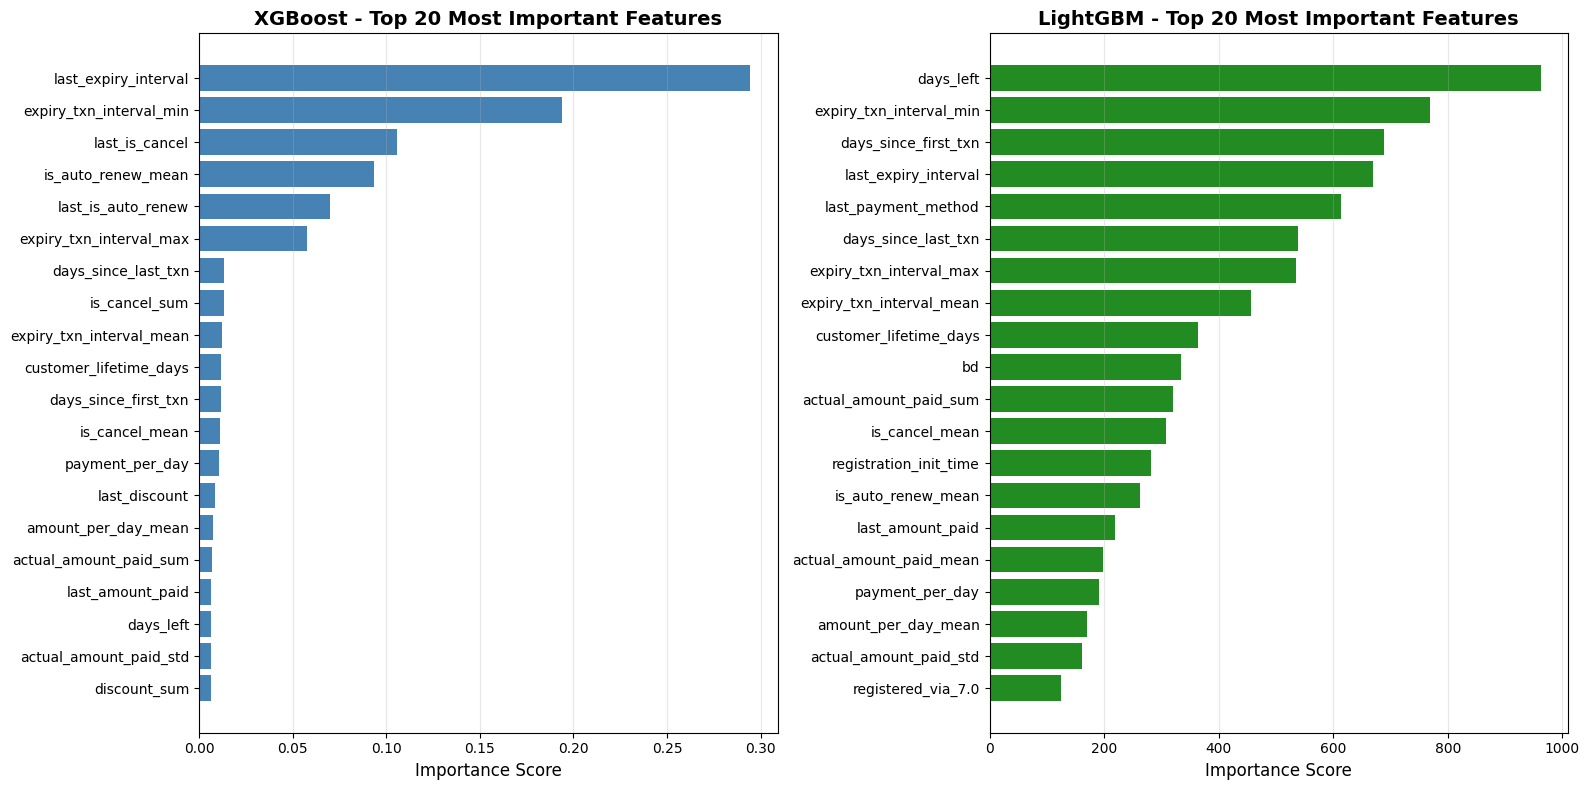


TOP 10 MOST IMPORTANT FEATURES

📊 XGBoost Top 10:
------------------------------------------------------------
last_expiry_interval                         0.2944
expiry_txn_interval_min                      0.1940
last_is_cancel                               0.1055
is_auto_renew_mean                           0.0936
last_is_auto_renew                           0.0702
expiry_txn_interval_max                      0.0579
days_since_last_txn                          0.0135
is_cancel_sum                                0.0134
expiry_txn_interval_mean                     0.0121
customer_lifetime_days                       0.0117

📊 LightGBM Top 10:
------------------------------------------------------------
days_left                                  962.0000
expiry_txn_interval_min                    769.0000
days_since_first_txn                       688.0000
last_expiry_interval                       669.0000
last_payment_method                        614.0000
days_since_last_txn        

In [11]:
# ==================== EXTRACT FEATURE IMPORTANCE FROM MODELS ====================

# Get feature importance from XGBoost
# .feature_importances_ returns importance score for each feature
# Higher score = more important for prediction
xgb_importance = pd.DataFrame({
    'feature': final_xgb.get_booster().feature_names,
    'importance': final_xgb.feature_importances_
}).sort_values('importance', ascending=False)

# Get feature importance from LightGBM
lgb_importance = pd.DataFrame({
    'feature': final_lgb.booster_.feature_name(),
    'importance': final_lgb.feature_importances_
}).sort_values('importance', ascending=False)

# ==================== VISUALIZE TOP 20 FEATURES ====================

# Create side-by-side plots for both models
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# XGBoost feature importance plot
# .barh() creates horizontal bar chart
axes[0].barh(
    xgb_importance.head(20)['feature'],      # Feature names (y-axis)
    xgb_importance.head(20)['importance'],   # Importance scores (x-axis)
    color='steelblue'
)
axes[0].set_xlabel('Importance Score', fontsize=12)
axes[0].set_title('XGBoost - Top 20 Most Important Features', fontsize=14, fontweight='bold')
axes[0].invert_yaxis()  # Highest importance at top
axes[0].grid(axis='x', alpha=0.3)

# LightGBM feature importance plot
axes[1].barh(
    lgb_importance.head(20)['feature'],
    lgb_importance.head(20)['importance'],
    color='forestgreen'
)
axes[1].set_xlabel('Importance Score', fontsize=12)
axes[1].set_title('LightGBM - Top 20 Most Important Features', fontsize=14, fontweight='bold')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# ==================== PRINT TOP 10 FEATURES ====================

print("\n" + "="*60)
print("TOP 10 MOST IMPORTANT FEATURES")
print("="*60)

print("\n📊 XGBoost Top 10:")
print("-" * 60)
for i, row in xgb_importance.head(10).iterrows():
    print(f"{row['feature']:40s} {row['importance']:>10.4f}")

print("\n📊 LightGBM Top 10:")
print("-" * 60)
for i, row in lgb_importance.head(10).iterrows():
    print(f"{row['feature']:40s} {row['importance']:>10.4f}")

# ==================== FIND COMMON IMPORTANT FEATURES ====================

# Features that appear in top 10 of both models
xgb_top10 = set(xgb_importance.head(10)['feature'])
lgb_top10 = set(lgb_importance.head(10)['feature'])
common_features = xgb_top10.intersection(lgb_top10)

print("\n" + "="*60)
print(f"🎯 COMMON IMPORTANT FEATURES (in both models' top 10):")
print("="*60)
if common_features:
    for feature in sorted(common_features):
        xgb_imp = xgb_importance[xgb_importance['feature'] == feature]['importance'].values[0]
        lgb_imp = lgb_importance[lgb_importance['feature'] == feature]['importance'].values[0]
        print(f"{feature:40s} XGB: {xgb_imp:>8.4f}  LGB: {lgb_imp:>8.4f}")
else:
    print("No common features in top 10")

# ==================== INTERPRETATION GUIDE ====================

print("\n" + "="*60)
print("📖 FEATURE IMPORTANCE INTERPRETATION")
print("="*60)
print("""
Feature importance tells us which features the model relies on most
when making predictions. Higher importance = more influential.

Common important features typically include:
  • days_left: Days remaining on membership (negative = expired)
  • last_is_auto_renew: Whether auto-renewal is enabled
  • total_transactions: Number of transactions (engagement)
  • cancel_rate: Historical cancellation rate
  • days_since_last_txn: Recency of last transaction
  • actual_amount_paid_sum: Total amount spent
  • payment_per_day: Daily spending rate

Business insights:
  • Focus retention efforts on users with negative days_left
  • Encourage auto-renewal (strong predictor of retention)
  • Monitor users with increasing days_since_last_txn
  • Reward high-value users (high actual_amount_paid_sum)
""")

print("="*60)
print("✅ Feature importance analysis complete!")
print("="*60)